Processing: image1.jpg
   Note: Image downsampled to 984x1200 for memory efficiency.


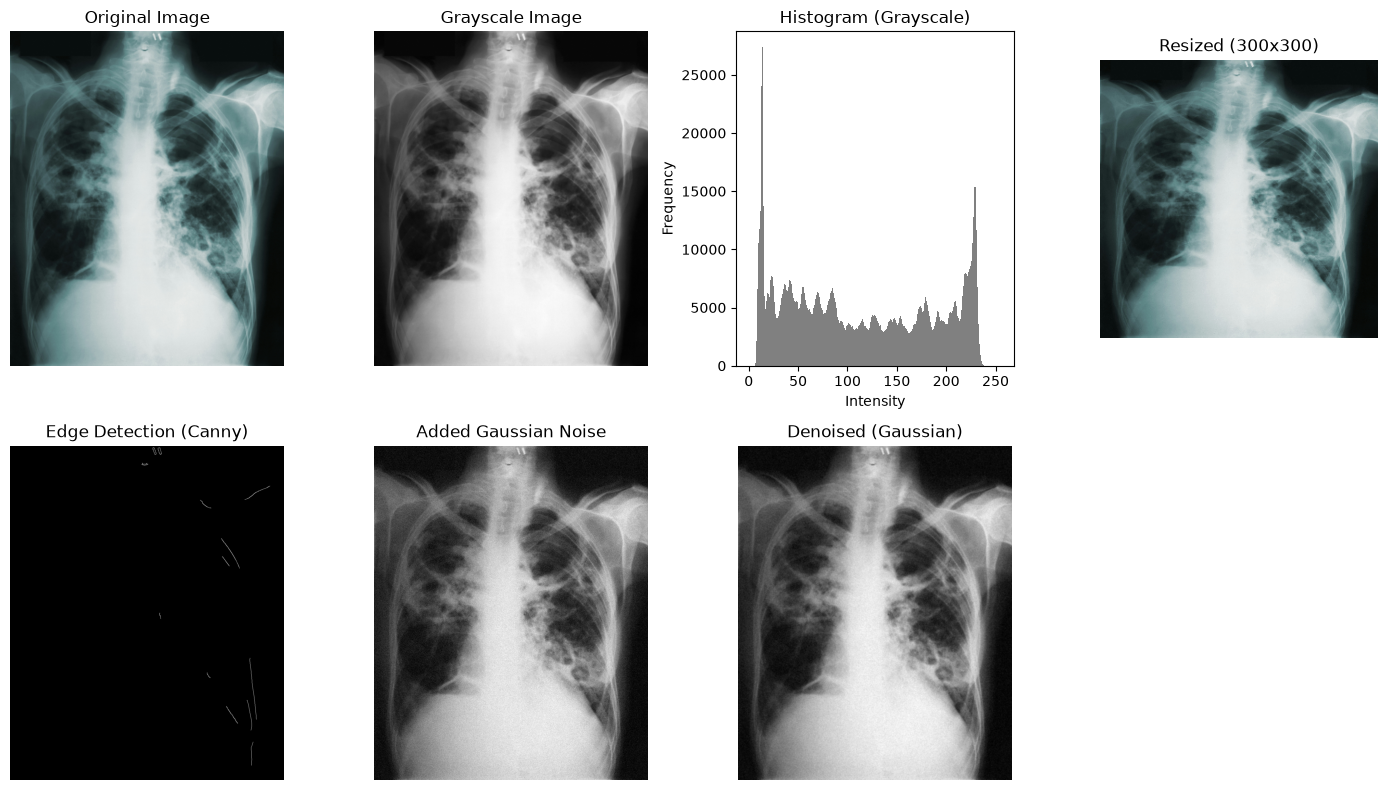

Processing: image2.jpg
   Note: Image downsampled to 1200x960 for memory efficiency.


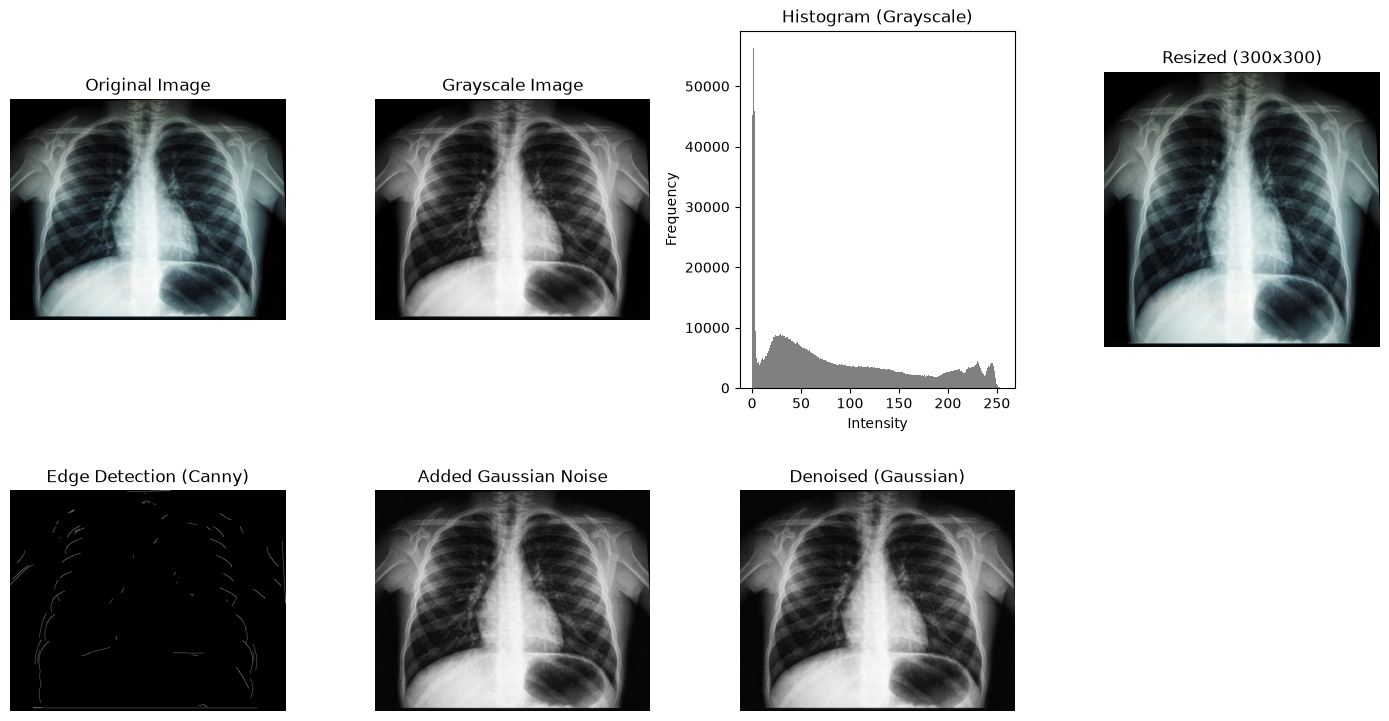

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def process_image(image_path, save_prefix):
    print(f"Processing: {image_path}")
    
    # 1. Load the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return
    
    # --- MEMORY PROTECTION FIX ---
    # If the image is larger than 1200 pixels, scale it down to prevent MemoryError
    max_dimension = 1200
    h, w = img.shape[:2]
    if max(h, w) > max_dimension:
        scale = max_dimension / max(h, w)
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
        print(f"   Note: Image downsampled to {img.shape[1]}x{img.shape[0]} for memory efficiency.")
    # ------------------------------

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 2. Grayscale conversion
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 3. Image resizing (Resizing to 300x300 pixels for the thumbnail step)
    img_resized = cv2.resize(img_rgb, (300, 300))
    
    # 4. Edge detection (Using the Canny edge detector)
    edges = cv2.Canny(img_gray, 100, 200)
    
    # 5. Noise addition (Adding Gaussian Noise)
    mean = 0
    sigma = 15  # Slightly lowered to keep it stable
    gaussian_noise = np.random.normal(mean, sigma, img_gray.shape).astype('int16')
    img_noisy = np.clip(img_gray.astype('int16') + gaussian_noise, 0, 255).astype('uint8')
    
    # 6. Noise removal (Using a Gaussian Filter)
    img_denoised = cv2.GaussianBlur(img_noisy, (5, 5), 0)
    
    # --- VISUALIZATION & PLOTTING ---
    # Downsample DPI to save massive amounts of RAM when saving
    fig = plt.figure(figsize=(14, 8))
    
    # Plot Original (RGB)
    plt.subplot(2, 4, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')
    
    # Plot Grayscale
    plt.subplot(2, 4, 2)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Grayscale Image")
    plt.axis('off')
    
    # Plot Histogram of Grayscale Image
    plt.subplot(2, 4, 3)
    plt.hist(img_gray.ravel(), bins=256, range=[0,256], color='gray')
    plt.title("Histogram (Grayscale)")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    
    # Plot Resized Image
    plt.subplot(2, 4, 4)
    plt.imshow(img_resized)
    plt.title("Resized (300x300)")
    plt.axis('off')
    
    # Plot Edge Detection
    plt.subplot(2, 4, 5)
    plt.imshow(edges, cmap='gray')
    plt.title("Edge Detection (Canny)")
    plt.axis('off')
    
    # Plot Noisy Image
    plt.subplot(2, 4, 6)
    plt.imshow(img_noisy, cmap='gray')
    plt.title("Added Gaussian Noise")
    plt.axis('off')
    
    # Plot Denoised Image
    plt.subplot(2, 4, 7)
    plt.imshow(img_denoised, cmap='gray')
    plt.title("Denoised (Gaussian)")
    plt.axis('off')
    
    plt.tight_layout()
    
    # Explicitly lowering dpi to 100 prevents heavy RAM spike on savefig
    plt.savefig(f"{save_prefix}_processed_results.png", dpi=100)
    plt.show()
    
    # Clear the figure from memory explicitly after showing it
    plt.close(fig)

# --- RUNNING THE CODE ---
process_image('image1.jpg', 'img1')
process_image('image2.jpg', 'img2')

## dataset_exploration

# Task 2: Medical Imaging Dataset Exploration

## Dataset 1: Chest X-Ray Images (Pneumonia)
* **Dataset Link:** [Kaggle - Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)
* **Type of Imaging Data:** X-ray (Chest)
* **Number of Images:** 5,856 images total
* **Available Classes or Labels:** 2 Classes (`Pneumonia` and `Normal`)
* **Dataset Imbalance:** Highly imbalanced. There are approximately 4,273 Pneumonia images compared to only 1,583 Normal images.
* **Challenges Observed:** The images contain random clinical artifacts, such as handwritten positioning markers (letters like 'R' or 'L' written on the scan) or medical wires. Images also vary wildly in resolution and aspect ratio.


## Dataset 2: Brain MRI Images for Brain Tumor Detection
* **Dataset Link:** [Kaggle - Brain MRI Images for Brain Tumor Detection](https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection)
* **Type of Imaging Data:** MRI (Magnetic Resonance Imaging)
* **Number of Images:** 253 images total
* **Available Classes or Labels:** 2 Classes (`Yes` for Tumor and `No` for No Tumor)
* **Dataset Imbalance:** Slightly imbalanced. It features 155 images with tumors and 98 images without tumors.
* **Challenges Observed:** The data sample size is extremely small, which presents a high risk of model overfitting. Furthermore, the scans are taken from different angles (axial, sagittal, and coronal views), introducing massive feature variance that a neural network would have to account for.